In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
# AdaBoost Algorithm
from sklearn.ensemble import AdaBoostClassifier
# Gradient Boosting 
from sklearn.ensemble import GradientBoostingClassifier
# XGBoost
import xgboost
from xgboost import XGBClassifier
from xgboost import plot_importance, to_graphviz, plot_tree
print("XGBoost version:",xgboost.__version__)

mycmap = "winter"
mpl.rcParams['image.cmap'] = mycmap
plt.rcParams['font.size'] = 13

XGBoost version: 3.2.0


## Read and split data

In [22]:
np.random.seed(12345)

dname="./DATA/"
str0="_XGB_26.dat"
fnamex=dname+'x'+str0
fnamey=dname+'y'+str0
x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y = np.loadtxt(fnamey)
y = y.astype(int)
N,L = len(x), len(x[0])

N_train = int(0.75*N)
x_train,y_train = x[:N_train],y[:N_train]
x_test,y_test = x[N_train:],y[N_train:]
print(f"N={N}, N_train={N_train}, L={L}")

N=5000, N_train=3750, L=4


### Scatter plot on \[i,j\] feature plane

[-31.608 -29.544   6.773   9.554] 0
[46.451 15.318 24.891 15.357] 0
[ 24.771  46.131 -49.161 -39.356] 0
[-20.13   15.641  30.981  37.218] 0
[46.465 22.369 14.248 21.745] 0


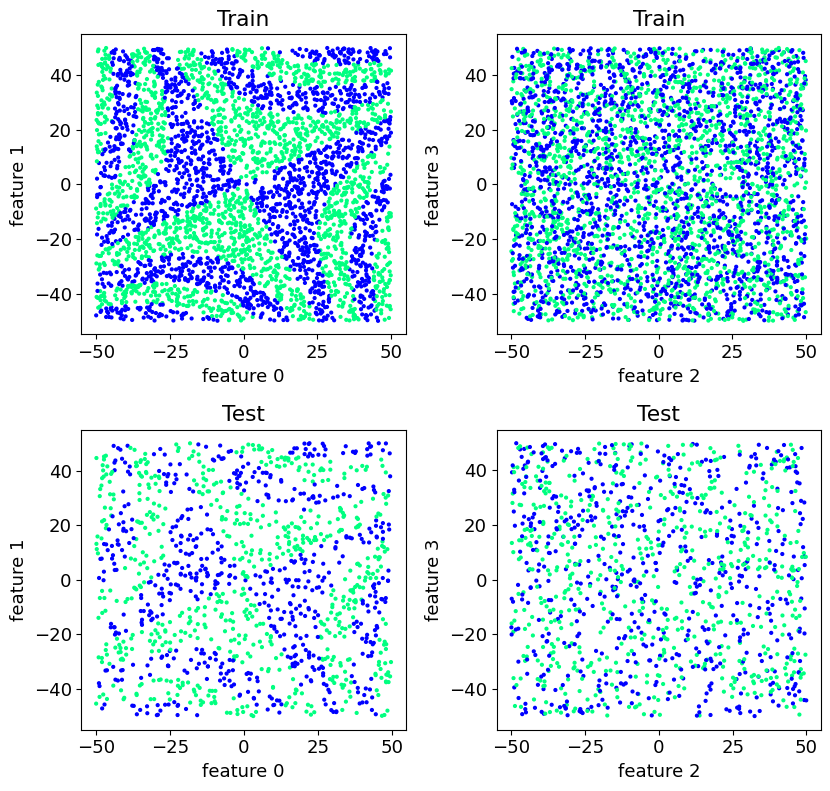

In [23]:
def scat(ax,x,y,i=0,j=1,s=4,title=""):
    # scatter plot of the data in the plane of features i and j
    ax.scatter(x[:,i],x[:,j],s=s,c=y) 
    ax.set_xlabel(f"feature {i}")
    ax.set_ylabel(f"feature {j}")
    ax.set_title(title)
for n in range(5):
    print(x[n],y[n])
fig,AX = plt.subplots(2,2,figsize=(8.5,8.1))
scat(AX[0,0],x_train,y_train,title="Train")
scat(AX[0,1],x_train,y_train,i=2,j=3,title="Train")
scat(AX[1,0],x_test,y_test,title="Test")
scat(AX[1,1],x_test,y_test,i=2,j=3,title="Test")
fig.tight_layout()
plt.show()

In [24]:
#Best Parameters
n_estimators  = 400
max_depth     = 15
learning_rate = 0.3

In [25]:
#Best model
model = XGBClassifier(
    seed=1,
    objective='binary:logistic',
    importance_type="gain",
    n_estimators=n_estimators,
    max_depth=max_depth,
    learning_rate=learning_rate,
    reg_lambda=1.0 
)

In [26]:
#fitting the model on the full train
model.fit(x_train, y_train);

gain
[0.52136105 0.3897809  0.04250212 0.0463558 ]


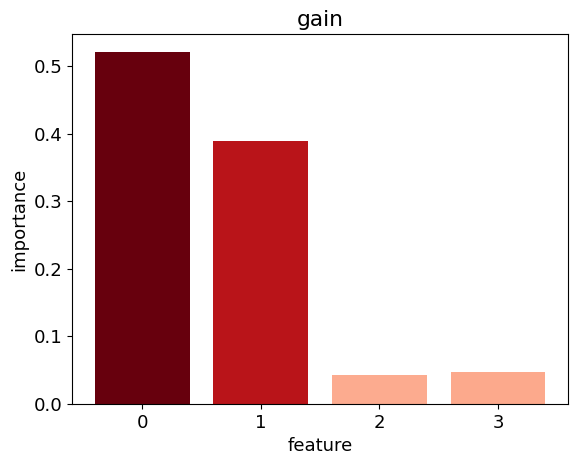

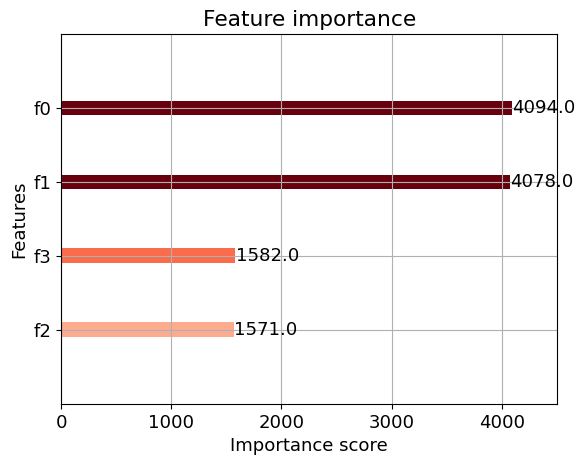

In [27]:
#Checking the importance of every features
print(model.importance_type)
print(model.feature_importances_)
# plot
my_cmap = plt.get_cmap("Reds")
# rescale the feature importances to the range [0.3,1] for better visualization
rescale = lambda y: 0.3 + 0.7 * (y - np.min(y)) / (np.max(y) - np.min(y))
plt.bar(range(len(model.feature_importances_)), model.feature_importances_,
        color=my_cmap(rescale(model.feature_importances_)))
plt.xlabel("feature")
plt.ylabel("importance")
plt.xticks(np.arange(L))
plt.title(model.importance_type)
plt.show()

rescale_r = lambda y: 0.3 + 0.7 * (np.max(y) - y) / (np.max(y) - np.min(y))
plot_importance(model,color=my_cmap(rescale_r(model.feature_importances_)))
plt.show()

In [28]:
#Classification function with features 0,1,2,3
def classify(clf=GradientBoostingClassifier()):
    
    clf.fit(x_train,y_train) # train the model on the training set
    y_hat = clf.predict(x_test) # predict the labels of the test set

    #defining accuracy as a global variable
    global accuracy
    accuracy = clf.score(x_test, y_test)
    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_test, y_test)),clf.score(x_test, y_test)))
    S=50 # size of the square grid
    dx = 1
    x_seq=np.arange(-S,S+dx,dx) # sequence of points for the grid
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L)) # grid of points
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] # only the first two features are used for the artificial grid
            q+=1
    y_plot= clf.predict(x_plot) # predict the labels of the grid points

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train[:],y_train,title="training set")
    fig.tight_layout()
    plt.suptitle("Model trained on features: 0,1,2,3", y=1.05)
    plt.show()

errors: 6.88%   Accuracy=0.931
shape of x_plot= (10201, 4)


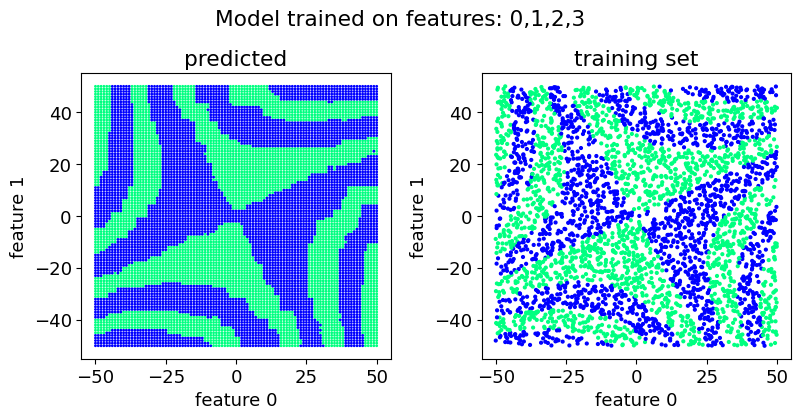

In [29]:
classify(model)

In [30]:
#redefining x_train and x_test without the feauture 3
x_train_012 = x_train[:, :3]
x_test_012 = x_test[:, :3]

In [31]:
#redifining the classification with the new datasets of training and test
def classify_012(clf=GradientBoostingClassifier()):

    clf.fit(x_train_012,y_train) 
    y_hat = clf.predict(x_test_012) 

    global accuracy_012
    accuracy_012 = clf.score(x_test_012, y_test)
    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_test_012, y_test)),clf.score(x_test_012, y_test)))
    S=50 
    dx = 1
    x_seq=np.arange(-S,S+dx,dx)
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L-1))
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] 
            q+=1
    y_plot= clf.predict(x_plot) 

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train_012[:],y_train,title="training set")
    fig.tight_layout()
    plt.suptitle("Model trained on features: 0,1,2", y=1.05)
    plt.show()

errors: 6.80%   Accuracy=0.932
shape of x_plot= (10201, 3)


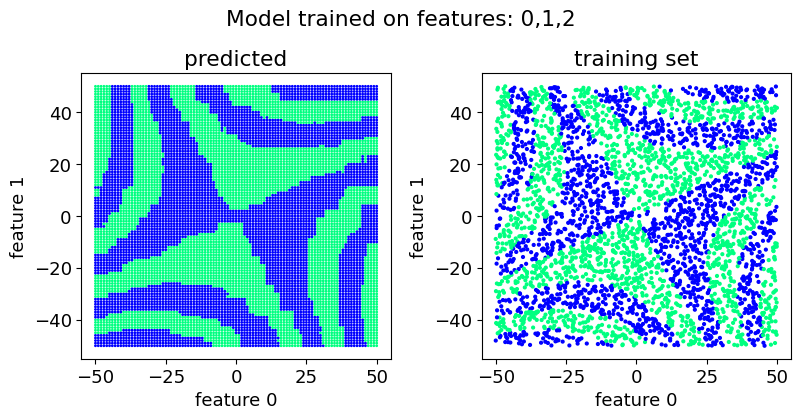

In [32]:
classify_012(model)

In [33]:
#redefining x_train and x_test without the feauture 3 and 2
x_train_01 = x_train[:, :2]
x_test_01 = x_test[:, :2]

In [34]:
#redifining the classification with the new datasets of training and test
def classify_01(clf=GradientBoostingClassifier()):

    clf.fit(x_train_01,y_train) 
    y_hat = clf.predict(x_test_01) 

    global accuracy_01
    accuracy_01 = clf.score(x_test_01, y_test)
    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_test_01, y_test)),clf.score(x_test_01, y_test)))
    S=50 
    dx = 1
    x_seq=np.arange(-S,S+dx,dx)
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L-2))
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] 
            q+=1
    y_plot= clf.predict(x_plot) 

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train_01[:],y_train,title="training set")
    fig.tight_layout()
    plt.suptitle("Model trained on features: 0,1", y=1.05)
    plt.show()

errors: 5.12%   Accuracy=0.949
shape of x_plot= (10201, 2)


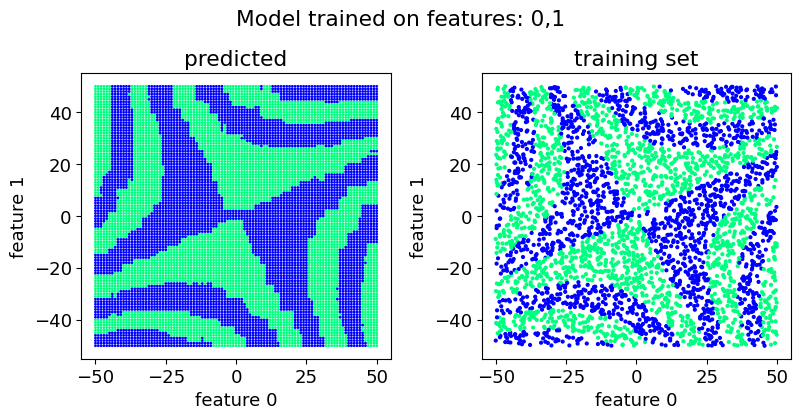

In [35]:
classify_01(model)

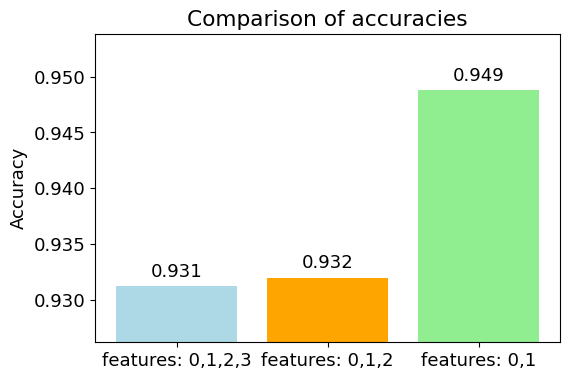

In [36]:
plt.figure(figsize=(6,4))
accuracies = [accuracy, accuracy_012, accuracy_01]
labels = ['features: 0,1,2,3', 'features: 0,1,2', 'features: 0,1']
bars = plt.bar(labels, accuracies, color=['lightblue','orange','lightgreen'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0005, f"{yval:.3f}", ha='center', va='bottom')


plt.ylim(min(accuracies)-0.005, max(accuracies)+0.005) 
plt.ylabel("Accuracy")
plt.title("Comparison of accuracies")
plt.show()

## Comment on accuracies
As we can see from the plot the accuracy using only feautures 0 and 1 is higher than the others, that's because feutures 2 and 3 are not informative about the dataset.